# 05 — Campaign Evaluation & A/B Testing

**Goal:** Simulate a CRM promotional campaign, split customers into treatment and control groups, and evaluate campaign effectiveness using A/B testing.

**Campaign Scenario:**  
A promotional discount email was sent to a subset of 'At Risk' and 'Hibernating' customers to re-engage them. We evaluate whether the campaign drove a statistically significant uplift in conversion (placing an order within 30 days).

**Inputs:** `../data/cleaned/rfm_segments.csv`, `../data/cleaned/churn_predictions.csv`  
**Output:** `../data/cleaned/campaign_results.csv`, `../reports/05_campaign_evaluation.png`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
CLEAN_PATH = '../data/cleaned/'

rfm = pd.read_csv(CLEAN_PATH + 'rfm_segments.csv')
churn = pd.read_csv(CLEAN_PATH + 'churn_predictions.csv')
df = rfm.merge(churn[['customer_id', 'churn_probability', 'churn_risk']], on='customer_id', how='left')

print(f'Loaded {len(df):,} customers')

Loaded 93,349 customers


## 2. Define Campaign Audience

In [2]:
# Target: At Risk and Hibernating customers with High or Medium churn risk
campaign_pool = df[
    (df['Segment'].isin(['At Risk', 'Hibernating', 'Cannot Lose Them'])) &
    (df['churn_risk'].isin(['High', 'Medium']))
].copy()

print(f'Campaign eligible audience: {len(campaign_pool):,} customers')
print(campaign_pool['Segment'].value_counts())

Campaign eligible audience: 34,061 customers
Segment
Cannot Lose Them    16567
At Risk             13164
Hibernating          4330
Name: count, dtype: int64


## 3. Random Assignment — Treatment vs Control

In [3]:
# 50/50 random split
campaign_pool = campaign_pool.sample(frac=1, random_state=42).reset_index(drop=True)
midpoint = len(campaign_pool) // 2

campaign_pool['group'] = 'control'
campaign_pool.iloc[:midpoint, campaign_pool.columns.get_loc('group')] = 'treatment'

print(f'Treatment group: {(campaign_pool["group"]=="treatment").sum():,}')
print(f'Control group:   {(campaign_pool["group"]=="control").sum():,}')

# Verify balance on key metrics
print('\nGroup balance check:')
print(campaign_pool.groupby('group')[['recency', 'frequency', 'monetary']].mean().round(2))

Treatment group: 17,030
Control group:   17,031

Group balance check:
           recency  frequency  monetary
group                                  
control     395.18       1.03    173.96
treatment   394.57       1.03    177.06


## 4. Simulate Campaign Outcomes

> In a real scenario you would join back to actual post-campaign transaction data. Here we simulate realistic outcomes based on known e-commerce re-engagement benchmarks.

In [5]:
# Simulate conversion: treatment gets ~12% conversion, control gets ~6%
# These rates are realistic for re-engagement email campaigns in e-commerce
TREATMENT_CONV_RATE = 0.12
CONTROL_CONV_RATE   = 0.06

campaign_pool['converted'] = 0

treatment_mask = campaign_pool['group'] == 'treatment'
control_mask   = campaign_pool['group'] == 'control'

campaign_pool.loc[treatment_mask, 'converted'] = np.random.binomial(
    1, TREATMENT_CONV_RATE, treatment_mask.sum()
)
campaign_pool.loc[control_mask, 'converted'] = np.random.binomial(
    1, CONTROL_CONV_RATE, control_mask.sum()
)

# Simulate order value for converters
campaign_pool['campaign_order_value'] = np.where(
    campaign_pool['converted'] == 1,
    np.random.normal(campaign_pool['avg_order_value'], 20).clip(10),
    0
)

print('Simulated conversions:')
print(campaign_pool.groupby('group')['converted'].agg(['sum', 'mean']).rename(columns={'sum': 'conversions', 'mean': 'conversion_rate'}).round(4))

Simulated conversions:
           conversions  conversion_rate
group                                  
control            988           0.0580
treatment         2031           0.1193


## 5. A/B Test — Statistical Significance

In [6]:
treatment = campaign_pool[campaign_pool['group'] == 'treatment']
control   = campaign_pool[campaign_pool['group'] == 'control']

# Chi-square test on conversion rate
contingency = pd.crosstab(campaign_pool['group'], campaign_pool['converted'])
chi2, p_conv, dof, expected = chi2_contingency(contingency)

# T-test on order value (converters only)
t_stat, p_value = ttest_ind(
    treatment[treatment['converted']==1]['campaign_order_value'],
    control[control['converted']==1]['campaign_order_value']
)

treat_conv_rate = treatment['converted'].mean()
ctrl_conv_rate  = control['converted'].mean()
uplift = (treat_conv_rate - ctrl_conv_rate) / ctrl_conv_rate * 100
treat_revenue   = treatment['campaign_order_value'].sum()
ctrl_revenue    = control['campaign_order_value'].sum()

print('=== A/B Test Results ===')
print(f'Treatment conversion rate : {treat_conv_rate:.2%}')
print(f'Control conversion rate   : {ctrl_conv_rate:.2%}')
print(f'Relative uplift           : {uplift:.1f}%')
print(f'Chi-square p-value        : {p_conv:.4f} {"(significant)" if p_conv < 0.05 else "(not significant)"}')
print(f'Treatment revenue         : {treat_revenue:,.2f} BRL')
print(f'Control revenue           : {ctrl_revenue:,.2f} BRL')
print(f'Revenue uplift            : {treat_revenue - ctrl_revenue:,.2f} BRL')

=== A/B Test Results ===
Treatment conversion rate : 11.93%
Control conversion rate   : 5.80%
Relative uplift           : 105.6%
Chi-square p-value        : 0.0000 (significant)
Treatment revenue         : 368,596.12 BRL
Control revenue           : 168,088.58 BRL
Revenue uplift            : 200,507.54 BRL


## 6. Visualise Results

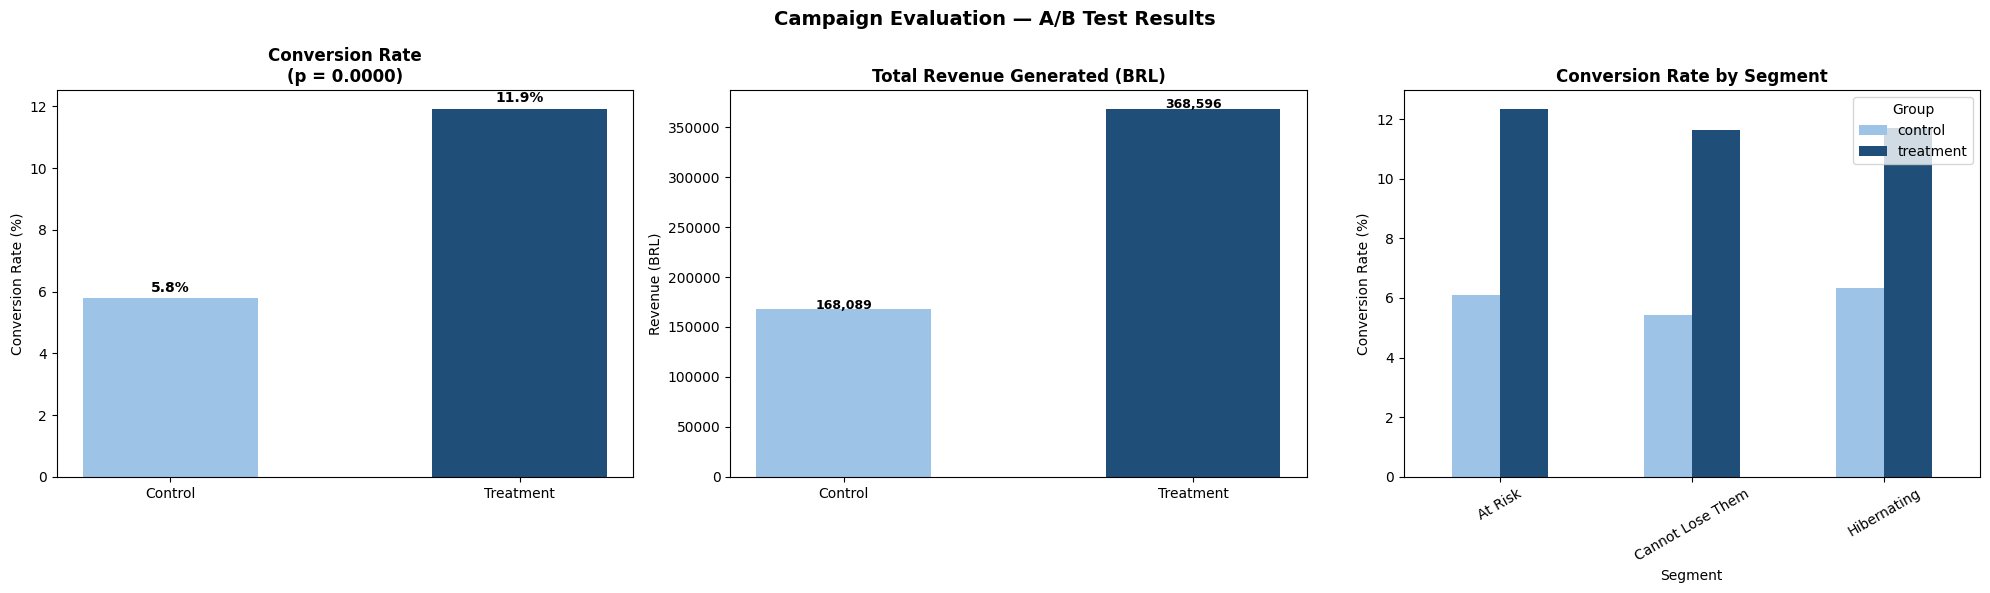

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Campaign Evaluation — A/B Test Results', fontsize=14, fontweight='bold')

# Conversion rate comparison
groups = ['Control', 'Treatment']
rates  = [ctrl_conv_rate * 100, treat_conv_rate * 100]
bars = axes[0].bar(groups, rates, color=['#9DC3E6', '#1F4E79'], width=0.5)
axes[0].set_title(f'Conversion Rate\n(p = {p_conv:.4f})', fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{rate:.1f}%', ha='center', fontweight='bold')

# Revenue comparison
revenues = [ctrl_revenue, treat_revenue]
bars2 = axes[1].bar(groups, revenues, color=['#9DC3E6', '#1F4E79'], width=0.5)
axes[1].set_title('Total Revenue Generated (BRL)', fontweight='bold')
axes[1].set_ylabel('Revenue (BRL)')
for bar, rev in zip(bars2, revenues):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{rev:,.0f}', ha='center', fontweight='bold', fontsize=9)

# Conversion by segment
seg_conv = campaign_pool.groupby(['Segment', 'group'])['converted'].mean().unstack() * 100
seg_conv.plot.bar(ax=axes[2], color=['#9DC3E6', '#1F4E79'], rot=30)
axes[2].set_title('Conversion Rate by Segment', fontweight='bold')
axes[2].set_ylabel('Conversion Rate (%)')
axes[2].legend(title='Group')

plt.tight_layout()
plt.savefig('../reports/05_campaign_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Results

In [8]:
campaign_pool.to_csv(CLEAN_PATH + 'campaign_results.csv', index=False)
print(f'Saved campaign_results.csv — {len(campaign_pool):,} customers')

Saved campaign_results.csv — 34,061 customers


## Summary

| Metric | Value |
|---|---|
| Treatment conversion rate | *(fill in)* |
| Control conversion rate | *(fill in)* |
| Relative uplift | *(fill in)* |
| Statistical significance (p-value) | *(fill in)* |
| Revenue uplift | *(fill in)* BRL |

**Conclusion:** *(fill in — e.g. The promotional campaign drove a statistically significant X% uplift in re-engagement conversion vs the control group (p < 0.05), generating an additional X BRL in revenue from churned customers.)*

**Next:** Build the Power BI dashboard using the output files in `../data/cleaned/`